# Error Analysis
In this Notebook we will explore where our model fails and find out ways to improve our models performance

- Train vs Test Prediction 
- Residual Analysis
- Feature based roc_auc performance
- Feature importance

In [7]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import time
import random
import statistics
import matplotlib.pyplot as plt
import joblib
from sklearn.pipeline import Pipeline
sys.path.append('..')  
from src.models.random_guessing import RandomGuessing
from src.models.zero_guessing import ZeroGuessing
from src.evaluation.evaluation_metrics import EvaluationMetrics
from sklearn.metrics import roc_auc_score


from src.data.loader import Loader
from src.data.splitter import split_data

loader = Loader().load()
X_train, X_test, y_train, y_test= split_data(loader.df)

In [8]:
model_path = Path.cwd().parent / "src" / "models" / "xgb" / "pipeline.pkl"
pipeline:Pipeline = joblib.load(filename=model_path)

## Train vs Test Set

In this section we compare the models performance on the trainingsset to the test set.
We try to figure out if the model is overfitting the data


In [9]:
y_train_pred = pipeline.predict_proba(X_train)[:, 1]
xgb_guessing_metrics = EvaluationMetrics(y=y_train, y_pred=y_train_pred)

In [10]:
y_test_pred = pipeline.predict_proba(X_test)[:, 1]
xgb_test_guessing_metrics = EvaluationMetrics(y=y_test, y_pred=y_test_pred)

In [11]:
xgb_guessing_metrics.print_eval_report(headline="Train Set")


Train Set
- Precision: 0.22116479583536686
- Recall: 0.9828302909813844
- F1: 0.36107698947578104
- ROC-AUC: 0.9883883669897299


In [12]:
xgb_test_guessing_metrics.print_eval_report(headline="Test Set")


Test Set
- Precision: 0.17992669253988788
- Recall: 0.8213582677165354
- F1: 0.2951892465511143
- ROC-AUC: 0.9201122569732031


The model extremely overfits the training data. 
Train prediction compared to test prediction is singnifficantly better.
To tacke this problem, we will increase the gamma param in the tuning process

## Residual Analysis
in this section we create a new df containing the true value y, our predicted value y^ and its difference

In [7]:
residuals = y_test - y_test_pred

error_df = pd.DataFrame({
    'y': y_test,
    'y_pred': y_test_pred,
    'residual': residuals
})

In [8]:
error_df["residual"].mean()

np.float64(0.00556326903406943)

In [9]:
fraud_residuals   = error_df[error_df.y == 1]["residual"] # residuals for target = 1
legit_residuals   = error_df[error_df.y == 0]["residual"] # residuals for target = 0

print(f"Fraud Mean Residual: {fraud_residuals.mean():.4f}")   # should be extremely positive (constantly undererstimating y)
print(f"Legit Mean Residual: {legit_residuals.mean():.4f}")   


Fraud Mean Residual: 0.6331
Legit Mean Residual: -0.0168


we can see, that the model constantly is underestimating the fraud probability. That lets us conclude that too many fraud payments are nor being detected.


We can see that on average the model is predicting 36% risk for target y's, which is not enough.

## Feature Based ROC analysis
In this section we compare differerent feature valzes and their average ROC score.

This should help us gain insights on what data the modell does good and on what data the modell does bad

### Categorical Features

In [10]:
cat_cols = X_test.select_dtypes(include='object').columns.tolist()

/var/folders/4m/khzpjqdj6cl07kznw50hb5780000gn/T/ipykernel_11566/3632854767.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_test.select_dtypes(include='object').columns.tolist()


In [11]:
print(cat_cols)

['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']


In [14]:
ohe_cols     = ["ProductCD", "card4", "card6", "DeviceType"]
email_cols   = ["R_emaildomain", "P_emaildomain"]
ordinal_cols = ["M1", "M2", "M3", "M4", "M5", "M6", "M7", "M8", "M9",
                "id_12", "id_15", "id_16", "id_23", "id_27", "id_28", 
                "id_29", "id_30", "id_31", "id_33", "id_34", "id_35", 
                "id_36", "id_37", "id_38", "DeviceInfo"]


In [21]:
results = []

for group_name, cols in [("OHE", ohe_cols), ("Email", email_cols), ("Ordinal", ordinal_cols)]:
    for col in cols:
        for category in X_test[col].dropna().unique():
            mask = (X_test[col] == category).values
            
            if mask.sum() < 1000:
                continue
            if len(np.unique(y_test.values[mask])) < 2:
                continue
                
            auc = roc_auc_score(y_test.values[mask], y_test_pred[mask])
            results.append({
                "encoding":   group_name,
                "feature":    col,
                "category":   category,
                "auc":        auc,
                "n_samples":  mask.sum(),
            })

df_results = pd.DataFrame(results).sort_values("auc")
print(df_results.head(20))  # print worse 20 categorical features


   encoding        feature             category       auc  n_samples
59  Ordinal          id_31  ie 11.0 for desktop  0.838370       1175
55  Ordinal          id_30            Windows 7  0.839094       1601
33  Ordinal             M5                    T  0.871822      22982
7       OHE          card4             discover  0.872006       1257
40  Ordinal             M8                    T  0.873909      25642
36  Ordinal             M6                    F  0.885295      48855
41  Ordinal             M9                    T  0.888912      59924
37  Ordinal             M7                    F  0.889062      62248
42  Ordinal             M9                    F  0.891005      11906
26  Ordinal             M2                    T  0.892027      75461
28  Ordinal             M3                    T  0.892929      66951
2       OHE      ProductCD                    W  0.893214      93669
39  Ordinal             M8                    F  0.895278      46188
64  Ordinal          id_31   mobil

we can clearly see certain features performing worse than others. Most of the features however, have little to no relevance for the model (m1-m9).

We can clearly see that Procudt W is performing worse than other products of the same column. 

In [18]:
df_results.groupby("encoding")["auc"].mean()

encoding
Email      0.909203
OHE        0.919591
Ordinal    0.909522
Name: auc, dtype: float64

we can clearly see small to no difference at all comparing the different feature engineering methods performed on the categorical features

### Numerical Features

In [ ]:
numerical_cols = X_test.select_dtypes(include="number").columns.tolist()

results = []

for col in numerical_cols:
    # cut column values to 5 bins 
    bins = pd.qcut(X_test[col], q=5, duplicates="drop")
    
    for bin_label in bins.dropna().unique():
        mask = (bins == bin_label).values
        
        if mask.sum() < 1000:
            # if bin group has less than 1000 examples skip
            continue
        if len(np.unique(y_test.values[mask])) < 2:
            # if bin groups v values are not both 0 and 1, skip
            continue
        
        auc = roc_auc_score(y_test.values[mask], y_test_pred[mask])
        results.append({
            "feature":  col,
            "bin":      str(bin_label),
            "auc":      auc,
            "n_samples": mask.sum(),
        })

df_num_results = pd.DataFrame(results).sort_values("auc")
print(df_num_results.head(25))


    feature               bin       auc  n_samples
251     V75        (1.0, 3.0]  0.777184       1042
253     V76        (1.0, 5.0]  0.788621       2745
163     V13        (1.0, 6.0]  0.808240       2668
89       D2    (-0.001, 19.0]  0.819334      14001
194     V36        (1.0, 5.0]  0.823507       2281
150      V6        (1.0, 9.0]  0.824010       4261
152      V7        (1.0, 9.0]  0.840665       6352
142      V2        (1.0, 8.0]  0.842217       4304
127     D11    (-0.001, 21.0]  0.842960      34085
219     V53        (1.0, 4.0]  0.851672       1398
221     V54        (1.0, 4.0]  0.852112       3300
625   id_01       (-5.0, 0.0]  0.855483       1727
98       D4        (0.0, 5.0]  0.858261       3775
540    V282       (1.0, 16.0]  0.862254      12207
542    V283       (1.0, 56.0]  0.863297      19156
139     D15       (0.0, 21.0]  0.863336      10183
101      D5     (46.0, 819.0]  0.868047      12367
583    V314   (29.0, 7519.87]  0.872944      23461
148      V5        (1.0, 6.0]  

In [26]:
for col in ["D2", "D11", "C2"]:
    bins = pd.qcut(X_test[col], q=5, duplicates="drop")
    grouped = pd.DataFrame({
        "bin": bins,
        "fraud": y_test.values
    }).groupby("bin")["fraud"].mean()
    print(f"\n{col}:")
    print(grouped)


D2:
bin
(-0.001, 19.0]    0.052925
(19.0, 62.0]      0.021605
(62.0, 150.0]     0.018583
(150.0, 343.0]    0.013059
(343.0, 639.0]    0.007880
Name: fraud, dtype: float64

D11:
bin
(-0.001, 21.0]    0.026669
(21.0, 137.0]     0.019534
(137.0, 385.0]    0.014808
(385.0, 670.0]    0.007862
Name: fraud, dtype: float64

C2:
bin
(-0.001, 1.0]    0.023468
(1.0, 2.0]       0.028860
(2.0, 4.0]       0.031549
(4.0, 1670.0]    0.078160
Name: fraud, dtype: float64


## Feature Importance
how often (% of trees) is this feature used for splitting the data

In [ ]:
model = pipeline.named_steps["model"] # extraxt model from pipeline
feature_names = pipeline[:-1].transform(X_test.iloc[:1]).columns # apply pipeline to first row (pipeline without model [-1]) to get column names after transformation

importances = pd.Series(
    model.feature_importances_, # get feature importances
    index=feature_names # assign index / names for better printing
).sort_values(ascending=False)

# print top 20 most important features
print(importances.head(20))


C4             0.060782
ProductCD_C    0.053361
V103           0.030843
C12            0.028637
C8             0.024520
C1             0.016414
V294           0.016128
V91            0.015690
C14            0.015078
V70            0.014184
V94            0.013032
V317           0.013028
C13            0.010905
V134           0.010853
V308           0.010413
V45            0.010133
addr2          0.009712
V69            0.009642
V40            0.009220
id_12          0.009048
dtype: float32


In [ ]:
# 20 most useless columns
print(importances.tail(20))

V113                     0.001061
V117                     0.000880
V41                      0.000000
V14                      0.000000
card6_charge card        0.000000
card6_debit or credit    0.000000
V27                      0.000000
V65                      0.000000
V68                      0.000000
V107                     0.000000
V120                     0.000000
V28                      0.000000
V89                      0.000000
V118                     0.000000
V119                     0.000000
V1                       0.000000
V121                     0.000000
V88                      0.000000
V122                     0.000000
V305                     0.000000
dtype: float32


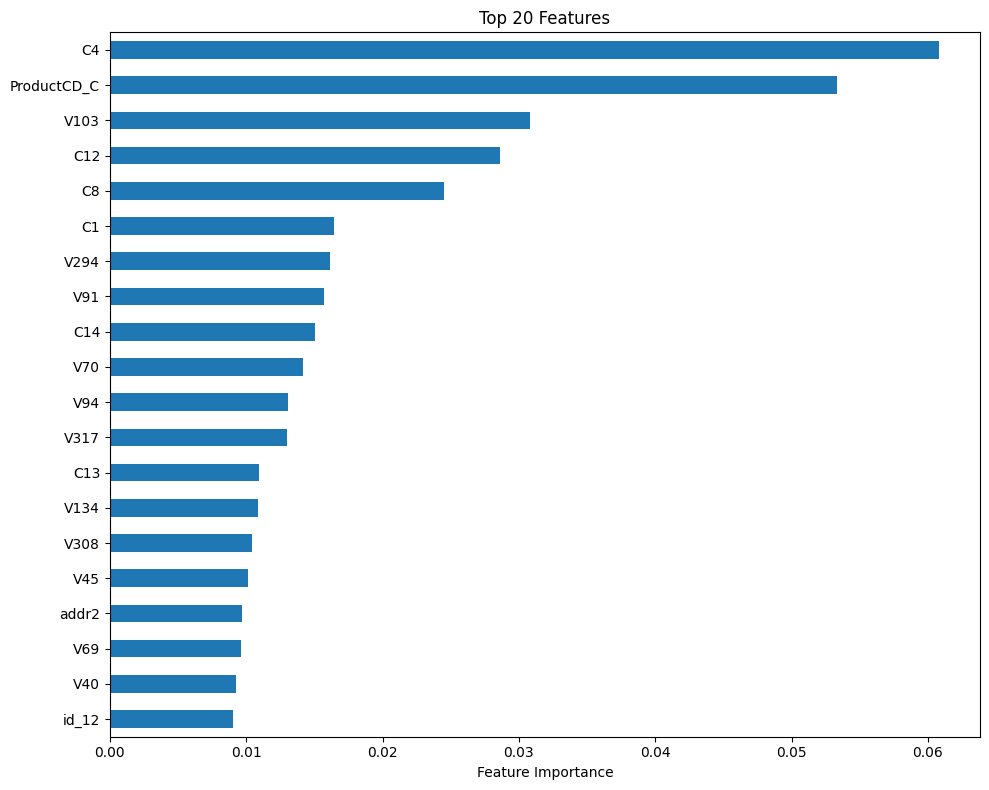

In [30]:
importances.head(20).plot.barh(figsize=(10, 8))
plt.xlabel("Feature Importance")
plt.title("Top 20 Features")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
